### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Task 1 -- Data Loading and Preparation**

#### **Load Dataset**

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **Keep: Survived, Pclass, Sex, Age, Fare**

In [3]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


#### **Drop Null Value**

In [4]:
#--Check null value
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
dtype: int64

In [5]:
df.dropna()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
885,0,3,female,39.0,29.1250
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
889,1,1,male,26.0,30.0000


In [6]:
#--Display shape and first 5 rows
print(f"Dataset Shape: {df.shape}")
print(f"Display Frist 5 rows:\n{df.head(5)}")


Dataset Shape: (891, 5)
Display Frist 5 rows:
   Survived  Pclass     Sex   Age     Fare
0         0       3    male  22.0   7.2500
1         1       1  female  38.0  71.2833
2         1       3  female  26.0   7.9250
3         1       1  female  35.0  53.1000
4         0       3    male  35.0   8.0500


# **Task 2 -- Survival Report**

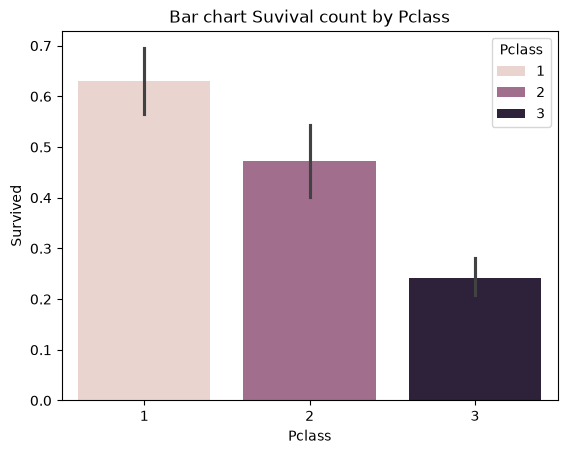

In [7]:
# Bar chart Suvival count by Pclass
plt.Figure(figsize=(12, 8))
sns.barplot(data=df, x ='Pclass', y = 'Survived', hue='Pclass')
plt.title("Bar chart Suvival count by Pclass")
plt.savefig("bar_chat_survive_pclass.png")
plt.show()

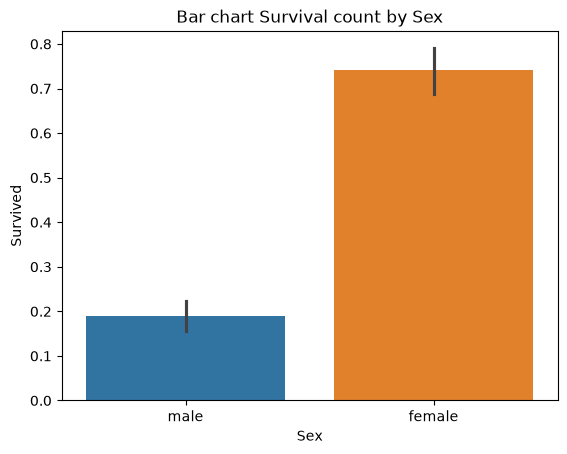

In [8]:
# Bar chart survival count by sex
sns.barplot(data=df, x='Sex', y='Survived', hue='Sex')
plt.title("Bar chart Survival count by Sex")
plt.show()

# **Task 3**

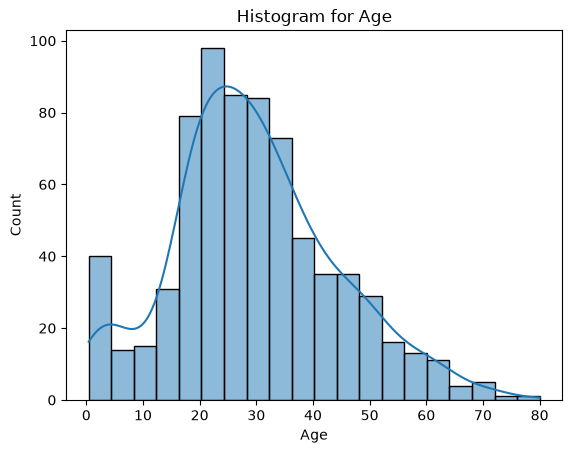

In [11]:
#Histogram with KDE by age
sns.histplot(data=df, x='Age', kde=True)
plt.title('Histogram for Age')
plt.show()

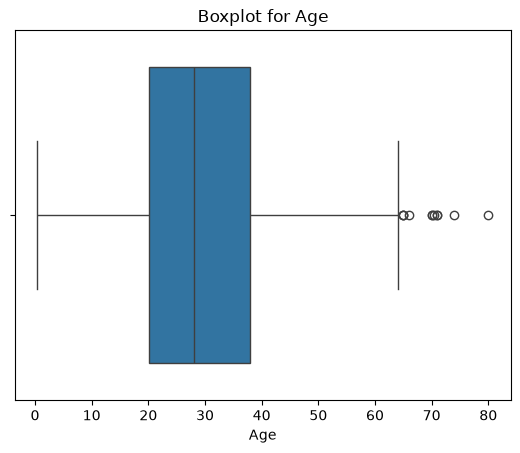

In [14]:
# Boxplot for Age
sns.boxplot(data=df, x='Age')
plt.title('Boxplot for Age')
plt.show()

# **Task 4**

In [19]:
# Correlation matrix for the all neumeric column
corr = df.corr(numeric_only=True)
corr

,Survived,Pclass,Age,Fare
Survived,1.000000,-0.338481,-0.077221,0.257307
Pclass,-0.338481,1.000000,-0.369226,-0.549500
Age,-0.077221,-0.369226,1.000000,0.096067
Fare,0.257307,-0.549500,0.096067,1.000000


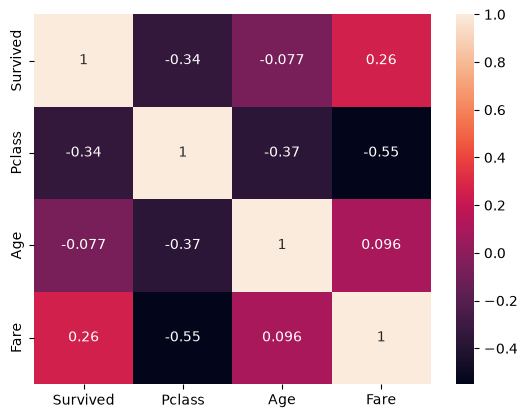

In [20]:
# Correlation in heatmap
sns.heatmap(corr, annot=True)
plt.show()

In [23]:
# Found the strongest positive and strongest negative correlation
unstack = corr.unstack()
unstack = unstack[unstack != 1]
print(f"Strongest Positive Correlation: {unstack.idxmax()}: {unstack.max().round(2)}")
print(f"Strongest Positive Correlation: {unstack.idxmin()}: {unstack.min().round(2)}")

Strongest Positive Correlation: ('Survived', 'Fare'): 0.26
Strongest Positive Correlation: ('Pclass', 'Fare'): -0.55
